In [1]:
#Import
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import flopy
import flopy.modflow as mf
import flopy.mt3d as mt
import flopy.utils as fu

In [2]:
#MODFLOW 2005
modelname = 'example' 
# mf_model = mf.Modflow(modelname = modelname, exe_name='mf2005.exe')
mf_model = mf.Modflow(modelname = modelname, exe_name='/home/jorge/github/flopy_documents/linux/mf2005')

In [ ]:
#DIS file
Lx = 310
Ly = 310
nrow = 31
ncol = 31
nlay = 1
delr = Lx / ncol
delc = Ly / nrow
top = np.ones((nrow, ncol))
botm = np.zeros((nrow, ncol))
perlen = 27

dis = mf.ModflowDis(mf_model, nlay, nrow, ncol, delr = delr, delc = delc, 
                    top = top, botm = botm, laycbd = 0, itmuni=4, perlen = perlen, 
                    nstp = 1)



# organization of the discretization of the simulation in space and time
# perlen array of floats - stress period lengths
#itmuni =  Time units default is 4
# nstp numger of time stesps in each stress period (default is one)
# laycbd = An array of flags indicating whether or not a layer has a Quasi-3D confining bed below it

In [4]:
# Output Control: Create a flopy output control object
oc = mf.ModflowOc(mf_model)

In [ ]:
#BCF file
laycon=0 #confined
tran=1.0 #transmissivity
bcf = flopy.modflow.mfbcf.ModflowBcf(mf_model,laycon=0, tran=1.0)

# tran (float or array of floats (nlay, nrow, ncol), optional) – transmissivity (only read if laycon is 0 or 2) (default is 1.0)
# laycon (int) – Layer type, confined (0), unconfined (1), constant T, variable S (2), variable T, variable S (default is 3)

In [6]:
#BAS file
ibound = np.ones((nlay, nrow, ncol)) #active
ibound[0, 0, :31] = -1 #constant head
ibound[0, 30, :31] = -1
ibound[0, :31, 0] = -1
ibound[0, :31, 30] = -1

strt=15 #starting head

ibound

array([[[-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
         -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
         -1., -1., -1., -1., -1., -1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1

In [ ]:
bas = mf.ModflowBas(mf_model, ibound = ibound, strt = strt)


# active 1>0
# constant head 1 < 0
# equal to zero inactive
# ibound dictates which cells participate in flow 
# ibound (array of ints, optional) – The ibound array (the default is 1).
# strt (array of floats, optional) – An array of starting heads (the default is 1.0).

In [ ]:
#PCG file
pcg = flopy.modflow.mfpcg.ModflowPcg(mf_model, mxiter=20, iter1=30, hclose=1e-03, rclose=1e-03, relax=1.0)

# mxiter (int) – maximum number of outer iterations. (default is 50)
# iter1 (int) – maximum number of inner iterations. (default is 30)
# hclose (float) – is the head change criterion for convergence. (default is 1e-5).
# rclose (float) – is the residual criterion for convergence. (default is 1e-5)
# relax (float) – is the relaxation parameter used with npcond = 1. (default is 1.0)

In [9]:
#CHD
#[lay, row, col, shead, ehead]

chd=15
chd_data = []
for c in range(30):
    dd = np.array([0, 0, c, chd, chd])
    chd_data.append(dd)
for c in range(31):
    dd = np.array([0, c, 30, chd, chd])
    chd_data.append(dd)
for c in range(30):
    dd = np.array([0, 30, c, chd, chd])
    chd_data.append(dd)
for c in range(1,30):
    dd = np.array([0, c, 0, chd, chd])
    chd_data.append(dd)
stress_period_data = {0:chd_data}

stress_period_data

{0: [array([ 0,  0,  0, 15, 15]),
  array([ 0,  0,  1, 15, 15]),
  array([ 0,  0,  2, 15, 15]),
  array([ 0,  0,  3, 15, 15]),
  array([ 0,  0,  4, 15, 15]),
  array([ 0,  0,  5, 15, 15]),
  array([ 0,  0,  6, 15, 15]),
  array([ 0,  0,  7, 15, 15]),
  array([ 0,  0,  8, 15, 15]),
  array([ 0,  0,  9, 15, 15]),
  array([ 0,  0, 10, 15, 15]),
  array([ 0,  0, 11, 15, 15]),
  array([ 0,  0, 12, 15, 15]),
  array([ 0,  0, 13, 15, 15]),
  array([ 0,  0, 14, 15, 15]),
  array([ 0,  0, 15, 15, 15]),
  array([ 0,  0, 16, 15, 15]),
  array([ 0,  0, 17, 15, 15]),
  array([ 0,  0, 18, 15, 15]),
  array([ 0,  0, 19, 15, 15]),
  array([ 0,  0, 20, 15, 15]),
  array([ 0,  0, 21, 15, 15]),
  array([ 0,  0, 22, 15, 15]),
  array([ 0,  0, 23, 15, 15]),
  array([ 0,  0, 24, 15, 15]),
  array([ 0,  0, 25, 15, 15]),
  array([ 0,  0, 26, 15, 15]),
  array([ 0,  0, 27, 15, 15]),
  array([ 0,  0, 28, 15, 15]),
  array([ 0,  0, 29, 15, 15]),
  array([ 0,  0, 30, 15, 15]),
  array([ 0,  1, 30, 15, 15]),
  arr

chd cell is defined through definition of layer (int), row (int), column (int), shead (float), ehead (float) shead is the head at the start of the stress period, and ehead is the head at the end of the stress period.

for c in range(30): # lay, row, column
    dd = np.array([0, 0, c, chd, chd])
    chd_data.append(dd)       # adds constant head of 15 to the top edge of the model 

# rows increase downward   (zero starts from the top left corner down)    |  ____  ->   columns
# columns increase to the right                                      row  V  |

rows north-south
cols east-west

for layers
0 Top layer            |
1 lower layer          V

adjust duration of time for each stress period in dis

perlen=[30,60,90] so this means kper 0 is 30 days long followed by kper 1 being 60 days and so on.

nper defines how many stress periods are present in the model.
everything uses this as a time reference

if the model consist of 5 nper, it is 5 stress periods long (time)
these portions of time don't have to be equal and their respective duration can be specified with perlen

CHD = head is fixed or specified according to stress period

if you only specify head for less then the totall stress periods in this model, the last specified stress period in CHD will be carried through to the following undefined stress periods.

In [ ]:
# constant heads
#What is a stress period, a period a time which simulation property is assumed to be constant



chd = mf.mfchd.ModflowChd(mf_model, stress_period_data=stress_period_data)

#stress_period_data (list of boundaries, recarrays, or dictionary of) – boundaries.

# 05/07/26 to continue again reviewing and documenting functions of this baseline modflow script
# this will be the foundation to my transport simulation.

In [11]:
#WELL
#[lay, row, col, pumping rate]

pumping_rate = 100 #m3/d
wel_sp1 = [[0, 15, 15, pumping_rate]]
stress_period_data = {0: wel_sp1}

wel = flopy.modflow.ModflowWel(mf_model, stress_period_data=stress_period_data)

In [12]:
#LMT Linkage with MT3DMS for multi-species mass transport modeling
lmt = flopy.modflow.ModflowLmt(mf_model, output_file_name='mt3d_link.ftl')

In [13]:
#Write input files
mf_model.write_input()

# run the model
mf_model.run_model()

FloPy is using the following executable to run the model: ../linux/mf2005

                                  MODFLOW-2005     
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUND-WATER FLOW MODEL
                             Version 1.12.00 2/3/2017                        

 Using NAME file: example.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2026/05/06 20:35:34

 Solving:  Stress period:     1    Time step:     1    Ground-Water Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/05/06 20:35:34
 Elapsed run time:  0.005 Seconds

  Normal termination of simulation


(True, [])

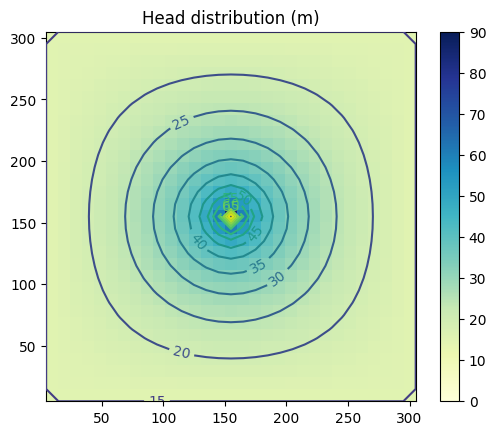

In [14]:
#Plot model results
import matplotlib.pyplot as plt
import flopy.utils.binaryfile as bf

# Create the headfile object
headobj = bf.HeadFile(modelname+'.hds')
head = headobj.get_data(totim=27)
times = headobj.get_times()

# Setup contour parameters
levels = np.arange(0, 90, 5)
extent = (delr/2., Lx - delr/2., delc/2., Ly - delc/2.)

# Make the plots
plt.subplot(1, 1, 1, aspect='equal')
plt.title('Head distribution (m)')
plt.imshow(head[0, :, :], extent=extent, cmap='YlGnBu', vmin=0., vmax=90.)
plt.colorbar()

contours = plt.contour(np.flipud(head[0, :, :]), levels=levels, extent=extent, zorder=10)
plt.clabel(contours, inline=1, fontsize=10, fmt='%d', zorder=11)

plt.show()

In [15]:
#MT3D-USGS
namemt3d='modelnamemt3d' 
# mt_model = mt.Mt3dms(modelname=namemt3d, version='mt3d-usgs', exe_name='MT3D-USGS_64.exe', modflowmodel=mf_model)
mt_model = mt.Mt3dms(modelname=namemt3d, version='mt3d-usgs', exe_name='/home/jorge/github/flopy_documents/linux/mt3dms', modflowmodel=mf_model)

In [16]:
#BTN file
icbund = np.ones((nlay, nrow, ncol))
icbund[0, 15, 15] = -1 #constant concentration

btn = flopy.mt3d.Mt3dBtn(mt_model, sconc=0.0, prsity=0.3, thkmin=0.01, munit='g', icbund=icbund)

In [17]:
#ADV file
mixelm = -1 #Third-order TVD scheme (ULTIMATE)
percel = 1 #Courant number PERCEL is also a stability constraint
adv = flopy.mt3d.Mt3dAdv(mt_model, mixelm=mixelm, percel=percel)

In [18]:
#GCG file
mxiter = 1 #Maximum number of outer iterations
iter1 = 200 #Maximum number of inner iterations
isolve = 3 #Preconditioner = Modified Incomplete Cholesky
gcg = flopy.mt3d.Mt3dGcg(mt_model, mxiter=mxiter, iter1=iter1, isolve=isolve)

In [19]:
#DSP file
al = 10 #longitudinal dispersivity
dmcoef = 0 #effective molecular diffusion coefficient
trpt = 0.1 #ratio of the horizontal transverse dispersivity to the longitudinal dispersivity
trpv = 0.01 #ratio of the vertical transverse dispersivity to the longitudinal dispersivity

dsp = mt.Mt3dDsp(mt_model, al=al, dmcoef=dmcoef, trpt=trpt, trpv=trpv)

In [20]:
#SSM file
itype = flopy.mt3d.Mt3dSsm.itype_dict()

#[K,I,J,CSS,iSSType] = layer, row, column, source concentration, type of sink/source: well-constant concentration cell 
ssm_data = {}
ssm_data[0] = [(0, 15, 15, 1.0, 2)]
ssm_data[0].append((0, 15, 15, 1.0, -1))

ssm = flopy.mt3d.Mt3dSsm(mt_model, stress_period_data=ssm_data)

In [21]:
#Write model input
mt_model.write_input()

#Run the model
mt_model.run_model()

FloPy is using the following executable to run the model: ../linux/mt3dms
 MT3DMS - Modular 3-D Multi-Species Transport Model [Version 5.30]
 Developed at University of Alabama for U.S. Department of Defense

 Using NAME File: modelnamemt3d.nam                                 

 STRESS PERIOD NO.    1

 TIME STEP NO.    1
 FROM TIME =   0.0000     TO    27.000    

 Transport Step:    1   Step Size:  0.6000     Total Elapsed Time:  0.60000    
 Outer Iter.  1  Inner Iter.  1:  Max. DC =  0.1112      [K,I,J]    1   17   17
 Outer Iter.  1  Inner Iter.  2:  Max. DC =  0.4276E-03  [K,I,J]    1   14   18
 Outer Iter.  1  Inner Iter.  3:  Max. DC =  0.4567E-05  [K,I,J]    1   17   17
 Transport Step:    2   Step Size:  0.6000     Total Elapsed Time:   1.2000    
 Outer Iter.  1  Inner Iter.  1:  Max. DC =  0.1064      [K,I,J]    1   16   17
 Outer Iter.  1  Inner Iter.  2:  Max. DC =  0.7866E-03  [K,I,J]    1   15   18
 Outer Iter.  1  Inner Iter.  3:  Max. DC =  0.1892E-05  [K,I,J]    1   

(False, [])

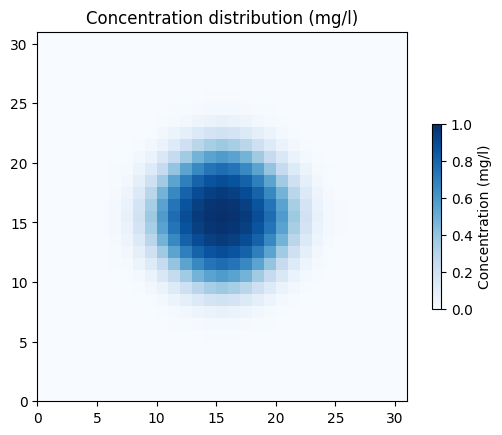

In [22]:
#Plot concentration results
conc = fu.UcnFile('MT3D001.UCN')
conc.plot(totim=times[-1], colorbar='Concentration (mg/l)', cmap='Blues')
plt.title('Concentration distribution (mg/l)')
plt.show()